In [1]:
import subprocess, sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "opencv-python",
    "scikit-learn",
    "tensorflow",
    "h5py",
    "tables",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])
print("Dependencias instaladas correctamente.")

Dependencias instaladas correctamente.


# Configuración de entorno (Colab / Local)

In [2]:
# ── Solo ejecutar si corres en Google Colab ───────────────────────────────────
# 1. Sube train_data.h5 y test_data.h5 a Google Drive en:  Mi unidad/ocular/
# 2. Para las imágenes, elige opción A (Drive) u opción B (Kaggle API)
# 3. Descomenta el bloque completo y ejecuta esta celda antes que las demás

# import os, shutil
# from google.colab import drive
# drive.mount('/content/drive')

# DRIVE_DIR = '/content/drive/MyDrive/ocular'

# Copiar .h5 a /content para lectura rápida (evita lentitud de Drive)
# shutil.copy(f'{DRIVE_DIR}/train_data.h5', '/content/train_data.h5')
# shutil.copy(f'{DRIVE_DIR}/test_data.h5',  '/content/test_data.h5')
# os.chdir('/content')

# Opción A — imágenes ya subidas a Drive:
# IMAGE_FOLDER_PATH = f'{DRIVE_DIR}/preprocessed_images'

# Opción B — descargar desde Kaggle (más rápido con muchas imágenes):
# shutil.copy(f'{DRIVE_DIR}/kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
# os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
# os.system('kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k -p /content --unzip')
# IMAGE_FOLDER_PATH = '/content/preprocessed_images'

# Verificar GPU disponible (Settings > Runtime type > T4 GPU)
# import tensorflow as tf
# print("GPU:", tf.config.list_physical_devices('GPU'))

# Librerias y dependencias

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Recall, Precision

# Carga de datos

In [4]:
train_data_path = 'train_data.h5'
test_data_path = 'test_data.h5'

train_data = pd.read_hdf(train_data_path)
test_data = pd.read_hdf(test_data_path)
train_data.head()

,ID,Patient Age,Patient Sex,target,filename,diagnostic,binary_target
6306,4584,42,Male,1,4584_left.jpg,D,0
2244,3126,41,Male,0,3126_right.jpg,N,1
1716,2553,54,Female,0,2553_right.jpg,N,1
6368,4653,68,Male,1,4653_left.jpg,D,0
4970,2618,58,Male,0,2618_left.jpg,N,1


Se separan los datos del objetivo

In [5]:
X_train, y_train = train_data.drop(columns=['target']), train_data['target']
X_test, y_test = test_data.drop(columns=['target']), test_data['target']
print(y_train.value_counts())

target
0    2298
1    1286
7     566
3     234
2     227
4     213
6     186
5     103
Name: count, dtype: int64


Se cargan las imagenes y se confirma que estas se puedan abrir

In [6]:
# Ruta a la carpeta de imagenes (relativa al notebook)
IMAGE_FOLDER_PATH = '../preprocessed_images'
IMAGE_SIZE = (128, 128)  # reducido para caber en RAM (~0.9 GB en lugar de ~3.8 GB a 224x224)

def load_images(filenames):
    images = []
    for filename in filenames:
        img_path = os.path.join(IMAGE_FOLDER_PATH, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, IMAGE_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype("float32")  # EfficientNetB0 incluye su propia normalizacion interna
            images.append(img)
        else:
            print(f"Warning: La imagen {filename} no se pudo cargar.")
    return np.array(images)

X_train_images = load_images(X_train['filename'])

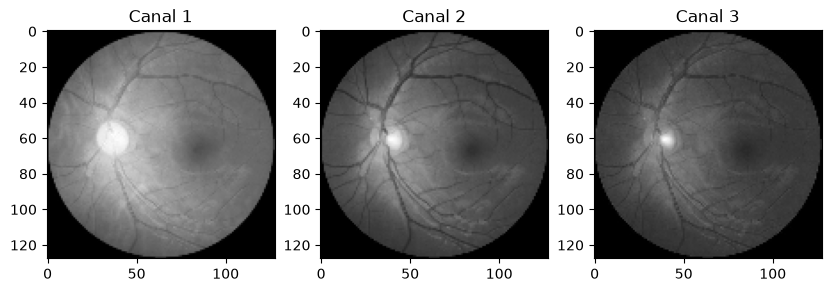

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(X_train_images[0][:,:,0], cmap="gray")
axs[0].set_title('Canal 1')
axs[1].imshow(X_train_images[0][:,:,1], cmap="gray")
axs[1].set_title('Canal 2')
axs[2].imshow(X_train_images[0][:,:,2], cmap="gray")
axs[2].set_title('Canal 3')
plt.show()

# Preparacion del Modelo

definicion del modelo

In [8]:
def build_transfer_model(input_shape=(128, 128, 3), num_classes=8):
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # base congelada: solo se entrena la cabeza densa

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu',
                               kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs), base_model

input_shape = (128, 128, 3)
model, base_model = build_transfer_model(input_shape)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,563 (16.71 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Se reinicia el indice de y_train

In [9]:
y_train = y_train.reset_index(drop=True)
print(y_train.head())

0    1
1    0
2    0
3    1
4    0
Name: target, dtype: int64


se aumentan las imagenes de las categorias menos representadas a traves de copias modificadas de las originales

In [10]:
def augment_images(images, labels):
    augmented_images = []
    augmented_labels = []

    for img, label in zip(images, labels):
        # Todas las clases minoritarias (2-7) reciben 3 copias aumentadas
        if label not in [0, 1]:
            h_flip_img = tf.image.flip_left_right(img)
            v_flip_img = tf.image.flip_up_down(img)

            h_flip_sat = tf.image.random_saturation(h_flip_img, lower=0.6, upper=1.4)
            augmented_images.append(h_flip_sat)
            augmented_labels.append(label)

            v_flip_sat = tf.image.random_saturation(v_flip_img, lower=0.6, upper=1.4)
            augmented_images.append(v_flip_sat)
            augmented_labels.append(label)

            hv_flip = tf.image.flip_left_right(tf.image.flip_up_down(img))
            augmented_images.append(hv_flip)
            augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

X_train_augmented, y_train_augmented = augment_images(X_train_images, y_train)

Ejemplo de imagenes generadas

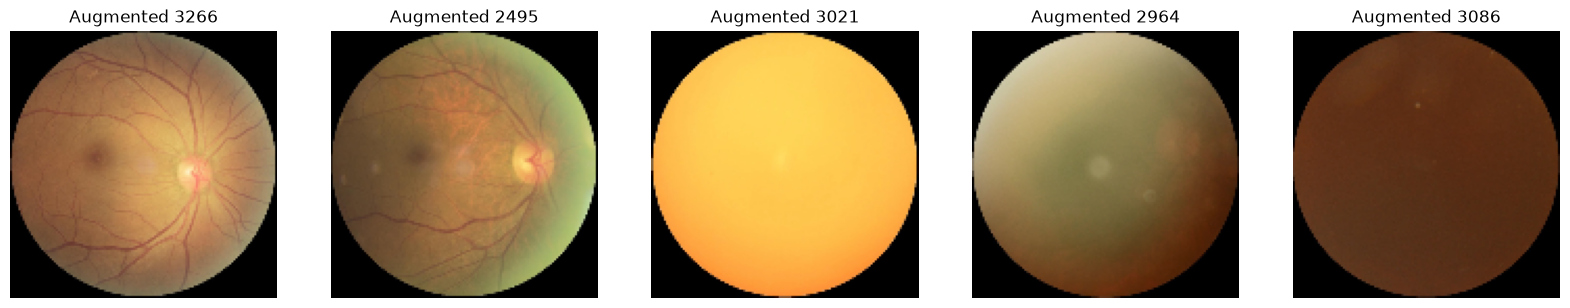

Augmented: 4587  |  Original: 5113


In [11]:
num_images_to_plot = 5
fig, axes = plt.subplots(1, num_images_to_plot, figsize=(20, 4))
for i in range(num_images_to_plot):
    idx = np.random.randint(0, len(X_train_augmented))
    axes[i].imshow(X_train_augmented[idx].astype(np.uint8))
    axes[i].set_title(f"Augmented {idx}")
    axes[i].axis("off")
plt.show()

print(f"Augmented: {X_train_augmented.shape[0]}  |  Original: {X_train_images.shape[0]}")

Se extrae un set de validacion del set de entrenamiento

In [12]:
validation_indices = []
for cls in sorted(y_train.unique()):
    cls_indices = y_train[y_train == cls].index
    n_val = max(1, int(len(cls_indices) * 0.2))
    chosen = np.random.choice(cls_indices, n_val, replace=False)
    validation_indices.extend(chosen)

validation_indices = np.array(validation_indices)

X_val = X_train_images[validation_indices]
y_val = y_train[validation_indices]

X_train_images = np.delete(X_train_images, validation_indices, axis=0)
y_train = y_train.drop(validation_indices).reset_index(drop=True)

print(f"Validation set: {X_val.shape[0]}  |  Training set: {X_train_images.shape[0]}")
print("Clases en validación:", dict(pd.Series(y_val.values).value_counts().sort_index()))

Validation set: 1019  |  Training set: 4094
Clases en validación: {0: np.int64(459), 1: np.int64(257), 2: np.int64(45), 3: np.int64(46), 4: np.int64(42), 5: np.int64(20), 6: np.int64(37), 7: np.int64(113)}


Se revisa la distribucion de la base de datos para entrenamiento

In [13]:
print("Class distribution in y_train:")
print(y_train.value_counts())

unique, counts = np.unique(y_train_augmented, return_counts=True)
print("\nClass distribution in y_train_augmented:")
print(dict(zip(unique, counts)))

Class distribution in y_train:
target
0    1839
1    1029
7     453
3     188
2     182
4     171
6     149
5      83
Name: count, dtype: int64

Class distribution in y_train_augmented:
{np.int64(2): np.int64(681), np.int64(3): np.int64(702), np.int64(4): np.int64(639), np.int64(5): np.int64(309), np.int64(6): np.int64(558), np.int64(7): np.int64(1698)}


Se combinan los datos originales con los generados

In [14]:
X_train_combined = np.concatenate((X_train_images, X_train_augmented), axis=0)
y_train_combined = np.concatenate((y_train, y_train_augmented), axis=0)
# No se hace shuffle aqui - Keras lo hace internamente en model.fit (shuffle=True por defecto)
print(f"Total training samples: {X_train_combined.shape[0]}")

Total training samples: 8681


# Entrenamiento del modelo

In [15]:
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_combined),
    y=y_train_combined
)
class_weights_dict = dict(enumerate(class_weights_array))
print("Class weights:", {k: round(v, 2) for k, v in class_weights_dict.items()})

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_combined,
    y_train_combined,
    epochs=120,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

Class weights: {0: np.float64(0.59), 1: np.float64(1.05), 2: np.float64(1.26), 3: np.float64(1.22), 4: np.float64(1.34), 5: np.float64(2.77), 6: np.float64(1.53), 7: np.float64(0.5)}
Epoch 1/120
272/272 ━━━━━━━━━━━━━━━━━━━━ 84s 249ms/step - accuracy: 0.3710 - loss: 2.5746 - val_accuracy: 0.3710 - val_loss: 1.8439 - learning_rate: 0.0010
Epoch 2/120
272/272 ━━━━━━━━━━━━━━━━━━━━ 73s 268ms/step - accuracy: 0.4082 - loss: 1.5736 - val_accuracy: 0.3798 - val_loss: 1.7310 - learning_rate: 0.0010
Epoch 3/120
272/272 ━━━━━━━━━━━━━━━━━━━━ 63s 232ms/step - accuracy: 0.4218 - loss: 1.4889 - val_accuracy: 0.2885 - val_loss: 1.8006 - learning_rate: 0.0010
Epoch 4/120
272/272 ━━━━━━━━━━━━━━━━━━━━ 59s 216ms/step - accuracy: 0.4220 - loss: 1.4558 - val_accuracy: 0.3386 - val_loss: 1.7339 - learning_rate: 0.0010
Epoch 5/120
272/272 ━━━━━━━━━━━━━━━━━━━━ 61s 225ms/step - accuracy: 0.4228 - loss: 1.4512 - val_accuracy: 0.3268 - val_loss: 1.7287 - learning_rate: 0.0010
Epoch 6/120
272/272 ━━━━━━━━━━━━━━━━━

# Resultados del Modelo

se cargan las imagenes del set de prueba

In [24]:
X_test_images = load_images(X_test['filename'])

se corre el modelo con los datos de prueba y se grafica el resultado en una matriz de confusion

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 304ms/step


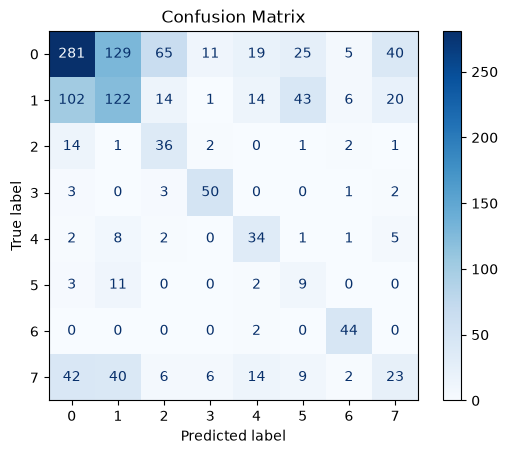

In [28]:
y_pred = model.predict(X_test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Se evalua la precision del modelo

In [30]:
from sklearn.metrics import accuracy_score, log_loss

accuracy = accuracy_score(y_test, y_pred_classes)
loss = log_loss(y_test, y_pred)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Loss: 1.3018
Accuracy: 0.4683


Se selecciona una imagen al azar para observar los filtros de activacion

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


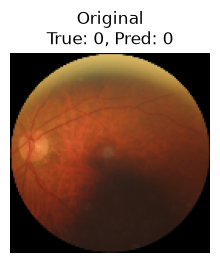

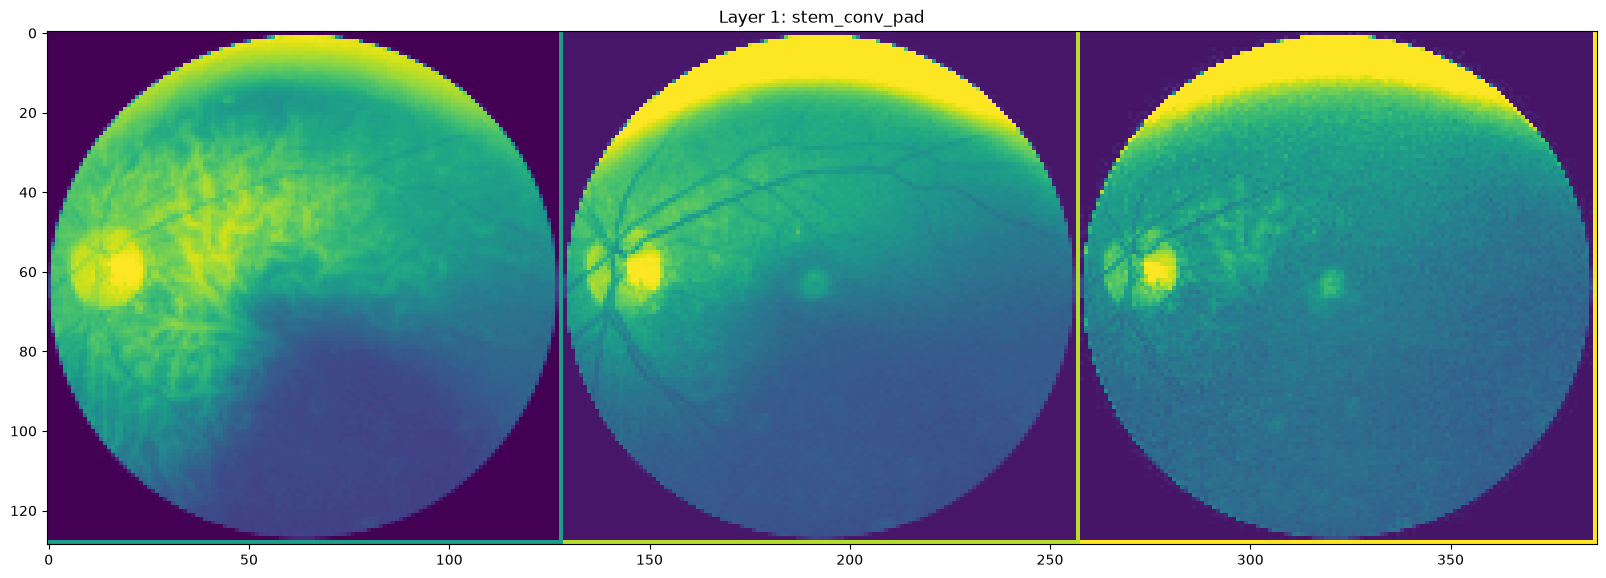

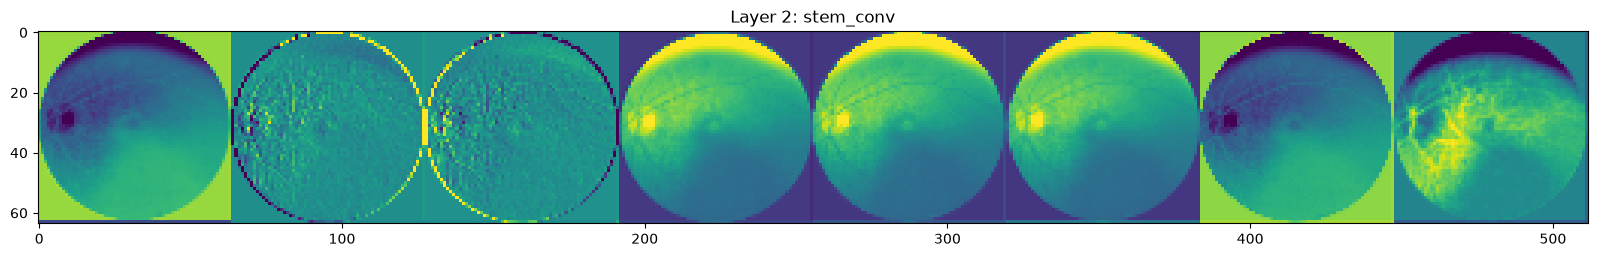

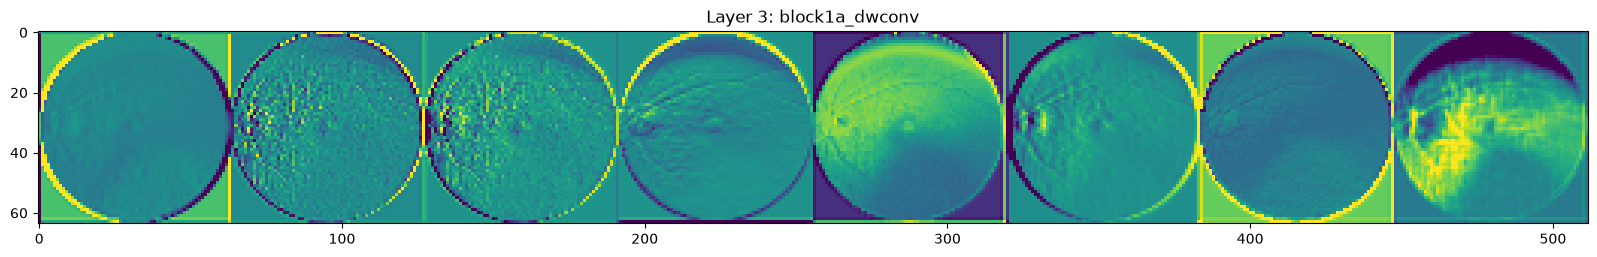

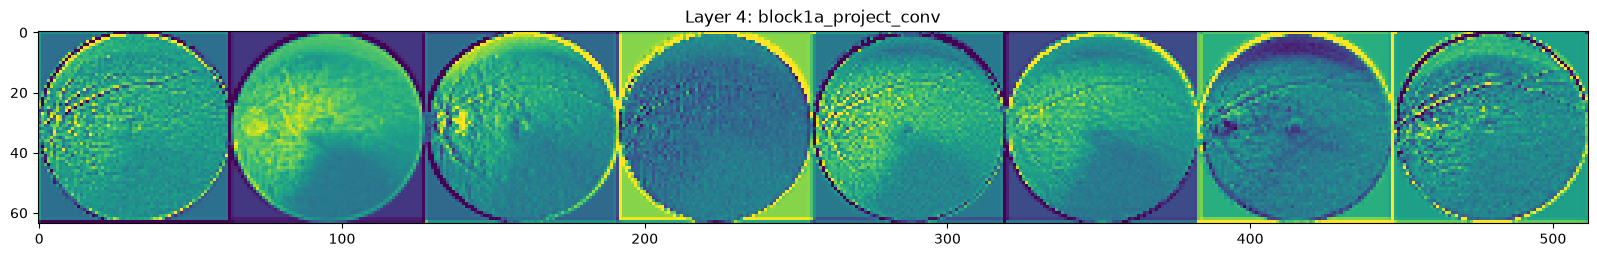

In [31]:
image_index = np.random.randint(0, len(X_test_images))
image = X_test_images[image_index]
true_class = y_test.iloc[image_index]
predicted_class = y_pred_classes[image_index]

# Con EfficientNetB0, las capas Conv2D están dentro del modelo base
conv_layers = [l for l in base_model.layers if 'conv' in l.name][:4]
layer_outputs = [l.output for l in conv_layers]
activation_model = tf.keras.models.Model(inputs=base_model.input, outputs=layer_outputs)
activations = activation_model.predict(np.expand_dims(image, axis=0))

plt.figure(figsize=(15, 5))
plt.subplot(1, len(activations) + 1, 1)
plt.imshow(image.astype(np.uint8))
plt.title(f"Original\nTrue: {true_class}, Pred: {predicted_class}")
plt.axis("off")

for i, activation in enumerate(activations):
    num_filters = min(activation.shape[-1], 8)
    size = activation.shape[1]
    display_grid = np.zeros((size, size * num_filters))
    for j in range(num_filters):
        x = activation[0, :, :, j]
        x -= x.mean()
        if x.std() != 0:
            x /= x.std()
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype("uint8")
        display_grid[:, j * size:(j + 1) * size] = x
    scale = 20. / num_filters
    plt.figure(figsize=(scale * num_filters, scale))
    plt.title(f"Layer {i + 1}: {conv_layers[i].name}")
    plt.grid(False)
    plt.imshow(display_grid, aspect="auto", cmap="viridis")
plt.show()

Se revisa la precision del modelo por categoria

In [32]:
from sklearn.metrics import classification_report

classes = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract',
           'Age-related Macular Degeneration', 'Hypertension', 'Myopia', 'Other']

report = classification_report(y_test, y_pred_classes, target_names=classes)
print(report)

                                  precision    recall  f1-score   support

                          Normal       0.63      0.49      0.55       575
            Diabetic Retinopathy       0.39      0.38      0.39       322
                        Glaucoma       0.29      0.63      0.39        57
                        Cataract       0.71      0.85      0.78        59
Age-related Macular Degeneration       0.40      0.64      0.49        53
                    Hypertension       0.10      0.36      0.16        25
                          Myopia       0.72      0.96      0.82        46
                           Other       0.25      0.16      0.20       142

                        accuracy                           0.47      1279
                       macro avg       0.44      0.56      0.47      1279
                    weighted avg       0.50      0.47      0.47      1279



In [33]:
model.save('dl_model.h5')
print("Modelo guardado en dl_model.h5")

Modelo guardado en dl_model.h5


# Phase 5 — Fine-tuning EfficientNetB0

Se descongelan las últimas 20 capas del modelo base para que se adapten a imágenes de retina.
Requiere GPU (Colab / Kaggle) — en CPU cada época tarda ~10-20 min.

In [34]:
# Phase 5: descongelar las últimas 20 capas de EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Capas entrenables: {sum(1 for l in base_model.layers if l.trainable)}/{len(base_model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tuning_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
fine_tuning_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-8, verbose=1)

history_ft = model.fit(
    X_train_combined,
    y_train_combined,
    epochs=50,
    validation_data=(X_val, y_val),
    batch_size=16,
    callbacks=[fine_tuning_stopping, fine_tuning_lr],
    class_weight=class_weights_dict
)

Capas entrenables: 20/238
Epoch 1/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.5979 - loss: 0.9690 - val_accuracy: 0.5025 - val_loss: 1.3461 - learning_rate: 1.0000e-05
Epoch 2/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 105s 194ms/step - accuracy: 0.5996 - loss: 0.9624 - val_accuracy: 0.5034 - val_loss: 1.3350 - learning_rate: 1.0000e-05
Epoch 3/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 103s 190ms/step - accuracy: 0.6015 - loss: 0.9519 - val_accuracy: 0.4975 - val_loss: 1.3362 - learning_rate: 1.0000e-05
Epoch 4/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 166s 306ms/step - accuracy: 0.6083 - loss: 0.9407 - val_accuracy: 0.4995 - val_loss: 1.3312 - learning_rate: 1.0000e-05
Epoch 5/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 186s 342ms/step - accuracy: 0.6135 - loss: 0.9222 - val_accuracy: 0.5054 - val_loss: 1.3156 - learning_rate: 1.0000e-05
Epoch 6/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 120s 221ms/step - accuracy: 0.6224 - loss: 0.8930 - val_accuracy: 0.5093 - val_loss: 1.3115 - learning_rate: 1.0000e-05
Epoch 7/50
543

40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 366ms/step


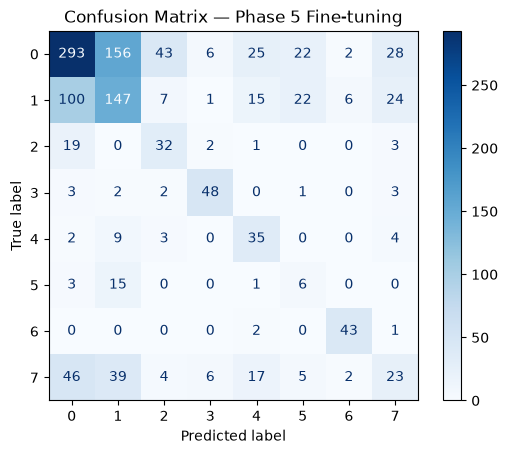

Loss:     1.2592
Accuracy: 0.4902

                                  precision    recall  f1-score   support

                          Normal       0.63      0.51      0.56       575
            Diabetic Retinopathy       0.40      0.46      0.43       322
                        Glaucoma       0.35      0.56      0.43        57
                        Cataract       0.76      0.81      0.79        59
Age-related Macular Degeneration       0.36      0.66      0.47        53
                    Hypertension       0.11      0.24      0.15        25
                          Myopia       0.81      0.93      0.87        46
                           Other       0.27      0.16      0.20       142

                        accuracy                           0.49      1279
                       macro avg       0.46      0.54      0.49      1279
                    weighted avg       0.51      0.49      0.49      1279



In [35]:
y_pred_ft = model.predict(X_test_images)
y_pred_ft_classes = np.argmax(y_pred_ft, axis=1)

cm_ft = confusion_matrix(y_test, y_pred_ft_classes)
disp_ft = ConfusionMatrixDisplay(confusion_matrix=cm_ft)
disp_ft.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix — Phase 5 Fine-tuning')
plt.show()

accuracy_ft = accuracy_score(y_test, y_pred_ft_classes)
loss_ft = log_loss(y_test, y_pred_ft)
print(f"Loss:     {loss_ft:.4f}")
print(f"Accuracy: {accuracy_ft:.4f}")

print()
print(classification_report(y_test, y_pred_ft_classes, target_names=classes))

In [36]:
model.save('dl_model_finetuned.keras')
print("Modelo fine-tuned guardado en dl_model_finetuned.keras")

Modelo fine-tuned guardado en dl_model_finetuned.keras
